In [160]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
from __future__ import annotations
from langchain_core.messages import HumanMessage, SystemMessage
import operator
from langgraph.types import Send
from dotenv import load_dotenv
load_dotenv()

True

In [161]:
class Task(BaseModel):
    id: int 
    title: str 
    brief: str = Field(description= "What to cover in a specific task")

In [162]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [163]:
class State(TypedDict):
    topic: str 
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [164]:
llm = ChatMistralAI(model = "mistral-small-latest")

In [165]:
def orchestractor(state: State):
    topic = state['topic']
    plan = llm.with_structured_output(Plan).invoke([
        SystemMessage(content="Create a blog plan with 5-7 sections on the following topic"),
        HumanMessage(content=f"TOPIC: {topic}")
    ])
    return {"plan": plan}

In [166]:
# orchestractor will give 5-7 plans and now we want that all the plans should get executed parallely at the same time
# For each plan same functions should get called at the same time but differenly for every plan so we use Send

# def fanout(state: State):
#     return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
#             for task in state["plan"].tasks]

def fanout(state: State):
    sends = []
    for task in state["plan"].tasks:
        send_obj = Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"]
            }
        )
        sends.append(send_obj)
    return sends

In [167]:
def worker(state: State) -> dict:
    task = state["task"]
    topic = state["topic"]
    plan = state["plan"]
    blog_title = plan.blog_title

    section_md = llm.invoke([
        SystemMessage(
            content = "Write one clear markdown section"
        ),
        HumanMessage(
            content = (
                f"BLOG TITLE: {blog_title}\n"
                f"TOPIC: {topic}\n"
                f"TASK: {task.brief}\n"
                f"TASK TITLE: {task.title}\n\n"
                "Return only the section content in markdown"
                )
        )
    ]).content.strip()
    return {"sections": [section_md]}

In [168]:
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"])
    final_md = f"# {title}\n\n{body}"

    # save to file
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    return {"final": final_md}

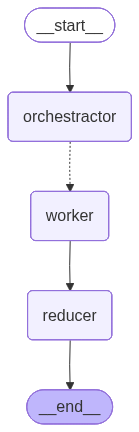

In [169]:
g = StateGraph(State)
g.add_node("orchestractor", orchestractor)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestractor")
g.add_conditional_edges("orchestractor", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [170]:
output = app.invoke({"topic": "write a blog on self attention layer"})
print(repr(output["plan"]))


Plan(blog_title='Understanding the Self-Attention Layer: A Deep Dive into Transformers', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain what self-attention is, its importance in deep learning, and where it is used (e.g., Transformers, NLP tasks). Provide a brief historical context and why it replaced traditional RNNs and CNNs in many tasks.'), Task(id=2, title='Mathematical Intuition Behind Self-Attention', brief='Break down the self-attention mechanism mathematically. Explain key components like queries, keys, values, dot-product attention, softmax, and weighted sums. Include formulas and a simple example to illustrate the process.'), Task(id=3, title='Step-by-Step Walkthrough of Self-Attention', brief='Provide a step-by-step guide on how self-attention works. Use a visual example (e.g., sentence embedding) to show how input tokens are transformed into queries, keys, and values, and how attention scores are computed and used to produce the output.'), Task(id=